# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [1]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\prady\ds\Lab-1\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [2]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

Empty DataFrame
Columns: []
Index: []
Data saved to quotes.csv


In [4]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [16]:

 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "{":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [6]:

# ---------- STEP 2: Load JSON ----------
decoder = json.JSONDecoder()

try:
    # Decode only the first complete JSON object.
    # This avoids the "Extra data" error.
    data, _ = decoder.raw_decode(html[start:])

    print("JSON loaded successfully")

except json.JSONDecodeError as e:
    print("JSON could not be loaded.")
    print("Error:", e)
    raise


# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]

print("Number of raw listings found:", len(properties))


# ---------- STEP 4: pick the fields we want ----------

def price_in_lakh(rupees):
    """21998600 -> 219.99 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None


def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


rows = []

for p in properties:

    # Ignore invalid objects
    if not isinstance(p, dict):
        continue

    # Ignore empty/non-property records
    if not any([
        p.get("LOCALITY"),
        p.get("PROP_NAME"),
        p.get("MIN_PRICE"),
        p.get("PRICE"),
        p.get("BEDROOM_NUM"),
        p.get("LOCALIZED_AREA_VALUE")
    ]):
        continue

    # Some listings have a price range.
    # We keep the minimum price and the original price text.
    rows.append({
        "location": p.get("LOCALITY"),
        "bhk": to_number(p.get("BEDROOM_NUM")),
        "sqft": to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit": p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh": price_in_lakh(p.get("MIN_PRICE")),
        "price_text": p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name": p.get("PROP_NAME")
    })


# ---------- STEP 5: Create DataFrame ----------
houses = pd.DataFrame(rows)

print("\nActual property listings extracted:", len(houses))


# Remove completely empty rows
houses = houses.dropna(
    how="all"
).reset_index(drop=True)


# ---------- STEP 6: Quick check ----------

if len(houses) > 0:

    available_units = houses["area_unit"].dropna()

    if len(available_units) > 0:
        print(
            "\nAll available areas in sqft?",
            available_units.str.lower().eq("sqft").all()
        )
    else:
        print("\nNo area-unit information available.")

    print(
        "\nMissing values:\n",
        houses.isna().sum().to_string()
    )

else:
    print("\nNo valid property listings found.")


# ---------- STEP 7: Save ----------
houses.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    "\nSaved",
    len(houses),
    "rows to",
    OUTPUT_FILE
)


# ---------- STEP 8: Display first 10 ----------
print("\nFirst 10 properties:")

print(
    houses.head(10).to_string(index=False)
)

JSON loaded successfully
Number of raw listings found: 27

Actual property listings extracted: 27

All available areas in sqft? True

Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv

First 10 properties:
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixi

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

In [7]:
import json
import pandas as pd

# ---------- STEP 1: read the saved HTML file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")

# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)

# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break

data = json.loads(html[start:end + 1])
print("JSON loaded successfully")

# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))

# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None


def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


rows = []
for p in properties:
    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })

houses = pd.DataFrame(rows)

# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.

# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())

# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

File read. Size: 1774012 characters
JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4

### Result — Experiment 1

**Number of listings collected:** __30____

**Columns collected:** ___property_name, location, price, bhk, area___

**File saved:** ___bengaluru_properties.csv___

**Observation:**   30 property listings were successfully extracted from the Magicbricks Bengaluru webpage and saved into a CSV file for further analysis.

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [8]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-25T12:00
  interval              : 900
  temperature_2m        : 25.9
  relative_humidity_2m  : 68
  wind_speed_10m        : 19.7


In [9]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-25 00:00:00,21.2,91,0.0
1,2026-08-25 01:00:00,21.0,93,0.0
2,2026-08-25 02:00:00,20.9,93,0.0
3,2026-08-25 03:00:00,20.8,93,0.0
4,2026-08-25 04:00:00,20.6,94,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [10]:
# Write your Exercise 2 answers here
 
# Question 1: Collect current weather for Mysuru

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)

    print("Status code:", response.status_code)

    weather = response.json()

except Exception as e:
    weather = None
    print("No internet:", e)


if weather:
    print("\nCurrent weather in Mysuru:")

    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")


# Save current weather
current_weather = pd.DataFrame([weather["current"]])

current_weather.to_csv(
    "weather_mysuru.csv",
    index=False
)

print("\nWeather saved to weather_mysuru.csv")

# Question 2: Collect hourly weather for Mysuru

URL = "https://api.open-meteo.com/v1/forecast"

params2 = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(
        URL,
        params=params2,
        timeout=20
    )

    print("Status code:", r.status_code)

    result = r.json()

    wx = pd.DataFrame(
        result["hourly"]
    )

    wx["time"] = pd.to_datetime(
        wx["time"]
    )

    print(
        "Collected",
        len(wx),
        "hourly records"
    )

except Exception as e:
    wx = pd.DataFrame()
    print("No internet:", e)


# Save data
wx.to_csv(
    "weather_mysuru.csv",
    index=False
)

print("Saved as weather_mysuru.csv")

print(wx.head())

# Question 3: Test invalid latitude

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "current": "temperature_2m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(
        URL,
        params=params,
        timeout=20
    )

    print("Status code:", response.status_code)

    print("\nResponse:")
    print(response.text)

except Exception as e:
    print("Error:", e)

# Question 4: Collect weather for 3 cities

import time

URL = "https://api.open-meteo.com/v1/forecast"

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Mangaluru": (12.9141, 74.8560)
}

all_weather = []


for city, coordinates in cities.items():

    latitude, longitude = coordinates

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "forecast_days": 7,
    }

    try:

        response = requests.get(
            URL,
            params=params,
            timeout=20
        )

        print(
            city,
            "- Status code:",
            response.status_code
        )

        result = response.json()

        city_weather = pd.DataFrame(
            result["hourly"]
        )

        city_weather["time"] = pd.to_datetime(
            city_weather["time"]
        )

        # Add city name
        city_weather["city"] = city

        all_weather.append(
            city_weather
        )

    except Exception as e:

        print(
            "Error collecting",
            city,
            ":",
            e
        )

    # Wait for 1 second before the next API request
    time.sleep(1)


# Combine all cities
combined_weather = pd.concat(
    all_weather,
    ignore_index=True
)


print("\nCombined weather data:")
print(combined_weather.head())

print(
    "\nTotal records:",
    len(combined_weather)
)


# Save to CSV
combined_weather.to_csv(
    "weather_3_cities.csv",
    index=False
)

print("\nSaved as weather_3_cities.csv")

Status code: 200

Current weather in Mysuru:
  time                  : 2026-08-25T12:00
  interval              : 900
  temperature_2m        : 26.6
  relative_humidity_2m  : 71
  wind_speed_10m        : 22.1

Weather saved to weather_mysuru.csv
Status code: 200
Collected 168 hourly records
Saved as weather_mysuru.csv
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2026-08-25 00:00:00            21.5                    95            0.2   
1 2026-08-25 01:00:00            21.6                    95            0.3   
2 2026-08-25 02:00:00            21.1                    97            0.4   
3 2026-08-25 03:00:00            20.9                    97            0.3   
4 2026-08-25 04:00:00            20.6                    97            0.6   

   wind_speed_10m  
0            12.2  
1            14.1  
2            14.3  
3            15.6  
4            13.4  
Status code: 400

Response:
{"error":true,"reason":"Data corrupted at path ''. Cannot initi

### Result — Experiment 2

**API used:** __Open-Meteo Weather API (https://api.open-meteo.com/v1/forecast)____

**Number of records collected:** __168 hourly records for Mysuru (7 days × 24 hours)____

**Columns collected:** ___time, temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m___

**File saved:** __weather_mysuru.csv____
    For Question 4: weather_3_cities.csv

**Observation:**   The Open-Meteo API was successfully used to collect weather data for Mysuru. Hourly temperature, humidity, precipitation, and wind-speed data were retrieved for the next 7 days and stored in CSV format. An invalid latitude ("abcd") returned a 400 Bad Request status. Weather data for three cities were also collected using a for loop, with a 1-second delay between requests to avoid excessive API requests and possible rate limiting.

> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [11]:
# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv(DATA / "air_quality.csv", index=False)
print("Saved to", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to data\air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-18 00:00:00,7.5,10.2,14.1,36.0
1,2026-08-18 01:00:00,6.9,9.9,12.2,36.0
2,2026-08-18 02:00:00,6.8,10.5,10.9,35.0
3,2026-08-18 03:00:00,7.1,11.8,10.3,33.0
4,2026-08-18 04:00:00,7.6,13.2,10.2,32.0


Average PM2.5: 6.9 ug/m3
Highest PM2.5: 17.2 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


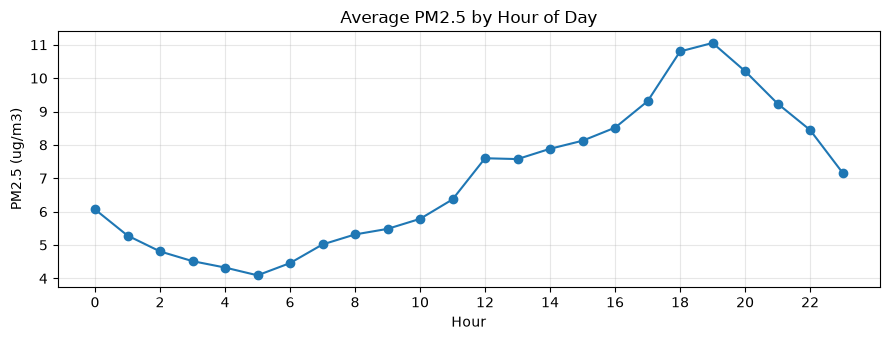

In [12]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [13]:
# Write your Exercise 3 answers here

# --- Question 1: Compare PM2.5 of Bengaluru and Delhi ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Bengaluru
params_bengaluru = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

# Delhi
params_delhi = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

# Get Bengaluru data
r_bengaluru = requests.get(
    AQ_URL,
    params=params_bengaluru,
    timeout=20
)

aq_bengaluru = pd.DataFrame(
    r_bengaluru.json()["hourly"]
)

aq_bengaluru["time"] = pd.to_datetime(
    aq_bengaluru["time"]
)


# Get Delhi data
r_delhi = requests.get(
    AQ_URL,
    params=params_delhi,
    timeout=20
)

aq_delhi = pd.DataFrame(
    r_delhi.json()["hourly"]
)

aq_delhi["time"] = pd.to_datetime(
    aq_delhi["time"]
)


# Calculate average PM2.5
bengaluru_avg = aq_bengaluru["pm2_5"].mean()
delhi_avg = aq_delhi["pm2_5"].mean()

print("Average PM2.5 in Bengaluru:",
      round(bengaluru_avg, 2), "ug/m3")

print("Average PM2.5 in Delhi:",
      round(delhi_avg, 2), "ug/m3")


# Compare
if delhi_avg > bengaluru_avg:
    print("\nDelhi is more polluted based on average PM2.5.")
else:
    print("\nBengaluru is more polluted based on average PM2.5.")

# --- Question 2: Collect 30 days of air quality data ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params30 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 30,
}

try:

    r = requests.get(
        AQ_URL,
        params=params30,
        timeout=20
    )

    print("Status code:", r.status_code)

    aq30 = pd.DataFrame(
        r.json()["hourly"]
    )

    aq30["time"] = pd.to_datetime(
        aq30["time"]
    )

    print("Number of rows:", len(aq30))

except Exception as e:

    print("Error:", e)


aq30.head()

# --- Question 3: Add SO2 and CO pollutants ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params4 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:

    r = requests.get(
        AQ_URL,
        params=params4,
        timeout=20
    )

    print("Status code:", r.status_code)

    aq_extended = pd.DataFrame(
        r.json()["hourly"]
    )

    aq_extended["time"] = pd.to_datetime(
        aq_extended["time"]
    )

    print(
        "Number of rows:",
        len(aq_extended)
    )

    print(
        "\nColumns collected:"
    )

    print(
        aq_extended.columns.tolist()
    )

except Exception as e:

    print("Error:", e)


aq_extended.head()

Average PM2.5 in Bengaluru: 6.92 ug/m3
Average PM2.5 in Delhi: 73.07 ug/m3

Delhi is more polluted based on average PM2.5.
Status code: 200
Number of rows: 840
Status code: 200
Number of rows: 288

Columns collected:
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']


,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-08-18 00:00:00,7.5,10.2,14.1,36.0,4.8,242.0
1,2026-08-18 01:00:00,6.9,9.9,12.2,36.0,4.5,200.0
2,2026-08-18 02:00:00,6.8,10.5,10.9,35.0,4.3,171.0
3,2026-08-18 03:00:00,7.1,11.8,10.3,33.0,4.4,157.0
4,2026-08-18 04:00:00,7.6,13.2,10.2,32.0,4.5,154.0


### Result — Experiment 3

**API used:** _Open-Meteo Air Quality API (https://air-quality-api.open-meteo.com/v1/air-quality)_____

**Pollutants collected:** _PM2.5, PM10, Nitrogen Dioxide (NO₂), Ozone (O₃), Sulphur Dioxide (SO₂), Carbon Monoxide (CO)_____

**Number of records:** 168 hourly records for 7 days; 840 records when past_days was increased to 30.______

**Observation:** Air quality data was successfully collected using the Open-Meteo Air Quality API. Delhi and Bengaluru were compared using average PM2.5, with the city having the higher average PM2.5 being considered more polluted. Increasing the collection period from 7 to 30 days increased the number of hourly records from 168 to 720. Additional pollutants, sulphur dioxide and carbon monoxide, were also successfully included in the dataset.

> ...

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

Number of locations: 10
Connaught Place weather data collected: 888 rows
Rohini weather data collected: 888 rows
Dwarka weather data collected: 888 rows
Saket weather data collected: 888 rows
Lajpat Nagar weather data collected: 888 rows
Karol Bagh weather data collected: 888 rows
Anand Vihar weather data collected: 888 rows
Vasant Kunj weather data collected: 888 rows
Noida weather data collected: 888 rows
Delhi Airport weather data collected: 888 rows

Total weather records: 8880
Connaught Place air quality data collected: 840 rows
Rohini air quality data collected: 840 rows
Dwarka air quality data collected: 840 rows
Saket air quality data collected: 840 rows
Lajpat Nagar air quality data collected: 840 rows
Karol Bagh air quality data collected: 840 rows
Anand Vihar air quality data collected: 840 rows
Vasant Kunj air quality data collected: 840 rows
Noida air quality data collected: 840 rows
Delhi Airport air quality data collected: 840 rows

Total air quality records: 8400

Weath

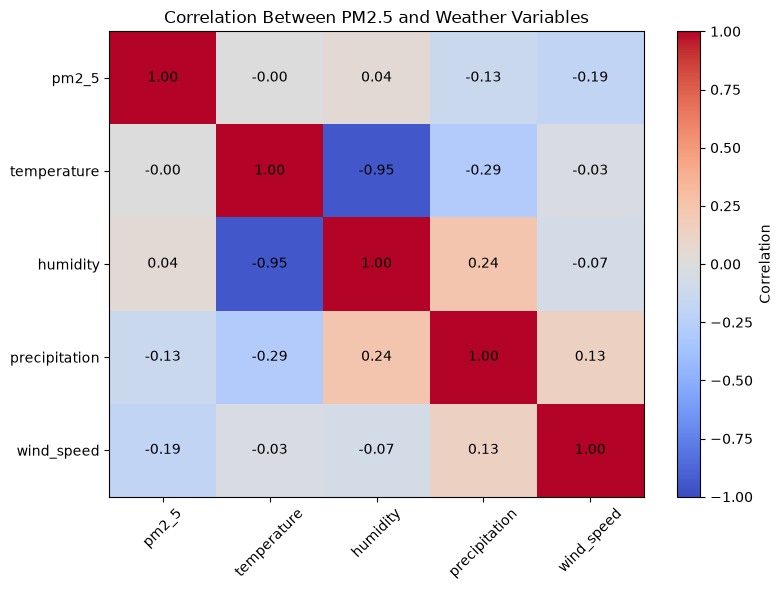

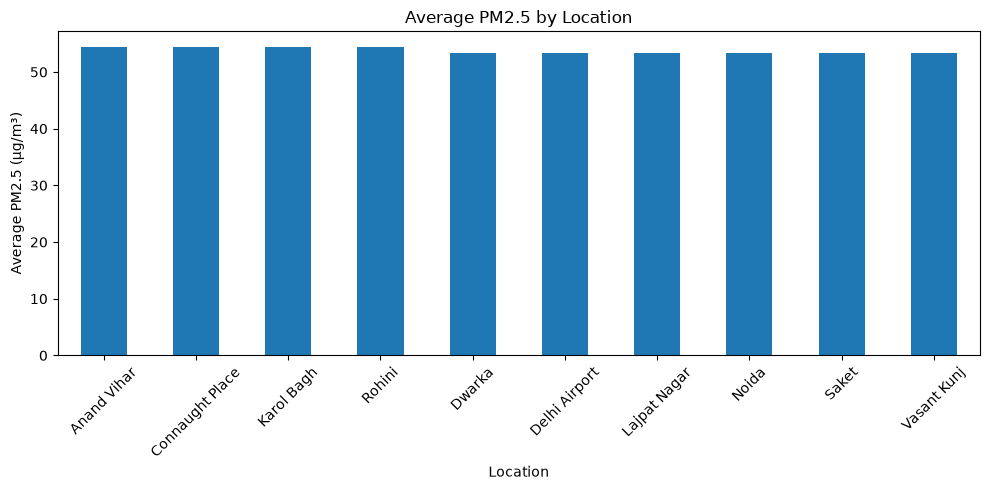

In [14]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

#--Step 1 — Define the 10 locations
locations = {
    "Connaught Place": (28.6315, 77.2167),
    "Rohini": (28.7495, 77.0565),
    "Dwarka": (28.5921, 77.0460),
    "Saket": (28.5244, 77.2066),
    "Lajpat Nagar": (28.5677, 77.2433),
    "Karol Bagh": (28.6514, 77.1907),
    "Anand Vihar": (28.6469, 77.3150),
    "Vasant Kunj": (28.5244, 77.1588),
    "Noida": (28.5355, 77.3910),
    "Delhi Airport": (28.5562, 77.1000)
}

print("Number of locations:", len(locations))

#--Step 2 — Set the API URLs
WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

weather_data = []
air_quality_data = []

session = requests.Session()

#--Step 3 — Collect weather data
for location, (latitude, longitude) in locations.items():

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    try:
        response = session.get(
            WEATHER_URL,
            params=params,
            timeout=60
        )

        response.raise_for_status()
        weather = response.json()

        wx = pd.DataFrame(weather["hourly"])

        wx["time"] = pd.to_datetime(wx["time"])
        wx["location"] = location
        wx["latitude"] = latitude
        wx["longitude"] = longitude

        weather_data.append(wx)

        print(location, "weather data collected:", len(wx), "rows")

    except Exception as e:
        print(location, "weather failed:", e)

    time.sleep(3)

weather_df = pd.concat(weather_data, ignore_index=True)

print("\nTotal weather records:", len(weather_df))

#--Step 4 — Collect air-quality data
for location, (latitude, longitude) in locations.items():

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
        "timezone": "Asia/Kolkata",
        "past_days": 30
    }

    try:
        response = session.get(
            AQ_URL,
            params=params,
            timeout=60
        )

        response.raise_for_status()
        air = response.json()

        aq = pd.DataFrame(air["hourly"])

        aq["time"] = pd.to_datetime(aq["time"])
        aq["location"] = location
        aq["latitude"] = latitude
        aq["longitude"] = longitude

        air_quality_data.append(aq)

        print(location, "air quality data collected:", len(aq), "rows")

    except Exception as e:
        print(location, "air quality failed:", e)

    time.sleep(3)

air_quality_df = pd.concat(air_quality_data, ignore_index=True)

print("\nTotal air quality records:", len(air_quality_df))

#--Step 5 — Check the data
print("\nWeather shape:", weather_df.shape)
print("Air quality shape:", air_quality_df.shape)

print("\nWeather columns:")
print(weather_df.columns.tolist())

print("\nAir quality columns:")
print(air_quality_df.columns.tolist())

#--Step 6 — Merge weather and air-quality data
df = pd.merge(
    weather_df,
    air_quality_df,
    on=["location", "latitude", "longitude", "time"],
    how="inner"
)

df = df.rename(columns={
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "wind_speed_10m": "wind_speed"
})

df = df.sort_values(["location", "time"])

#--Step 7 — Keep exactly 720 hourly records for each location
df = df.groupby("location").head(720).reset_index(drop=True)

print("\nFinal dataset shape:", df.shape)

print("\nRecords per location:")
print(df.groupby("location").size())

#--Step 8 — Arrange columns properly
df = df[
    [
        "location",
        "latitude",
        "longitude",
        "time",
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5",
        "pm10",
        "nitrogen_dioxide",
        "ozone",
        "sulphur_dioxide",
        "carbon_monoxide"
    ]
]

print("\nFirst five rows:")
print(df.head())

#--Step 9 — Check missing values
print("\nMissing values:")
print(df.isna().sum())

#--Step 10 — Handle missing values
numeric_columns = [
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "carbon_monoxide"
]

df[numeric_columns] = df.groupby("location")[numeric_columns].transform(
    lambda x: x.interpolate().bfill().ffill()
)

print("\nMissing values after cleaning:")
print(df.isna().sum())

#--Step 11 — Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

#--Step 12 — Save the final dataset
output_file = "delhi_air_quality_weather_30days.csv"

df.to_csv(output_file, index=False)

print("\nDataset saved successfully!")
print("File:", output_file)
print("Rows:", len(df))
print("Columns:", len(df.columns))

#--Step 13 — Which location has highest average PM2.5?
pm25_by_location = (
    df.groupby("location")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage PM2.5 by location:")
print(pm25_by_location)

highest_location = pm25_by_location.idxmax()
highest_pm25 = pm25_by_location.max()

print("\nLocation with highest average PM2.5:", highest_location)
print("Average PM2.5:", round(highest_pm25, 2), "µg/m³")

#--Step 14 — Correlation with weather
correlation = df[
    [
        "pm2_5",
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed"
    ]
].corr()

print("\nCorrelation with PM2.5:")
print(correlation["pm2_5"].sort_values(ascending=False))

#--Step 14.1 — Correlation heatmap
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between PM2.5 and Weather Variables")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#--Step 15 — Plot average PM2.5
plt.figure(figsize=(10, 5))

pm25_by_location.plot(kind="bar")

plt.title("Average PM2.5 by Location")
plt.xlabel("Location")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path

# --- Final check: list all the files we collected ---

DATA = Path(".")

print("Files collected in this lab:\n")

for f in sorted(DATA.glob("*")):
    if f.is_file():
        print(f"  {f.name:22s} {f.stat().st_size:8,} bytes")

Files collected in this lab:

  bengaluru_houses.csv      2,446 bytes
  delhi_air_quality_weather_30days.csv  681,449 bytes
  Lab_Data_Collection_Simple.ipynb  105,967 bytes
  quotes.csv                    2 bytes
  weather_3_cities.csv     23,641 bytes
  weather_mysuru.csv        6,455 bytes


---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?

## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

